In [1]:
%cd ..

/mnt/c/Users/asmaa/Desktop/Amr/Master's Thesis project archive/Master's Thesis v0.4


/home/asmaa/miniconda3/envs/Masters/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from optimizers import SOAP

In [4]:
import guides
import models
import samplers
import trainers
import utils

import torch
import numpy as np

In [5]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd
dx = (lambd / 10) * k_0

# normalized simulation lengths
substrate_length = (6 * lambd) * k_0
core_length = (2 * lambd) * k_0
cladding_length = (6 * lambd) * k_0

# refractive indices
n_substrate = 1.44
n_core = 1.55
n_cladding = 1.44

In [7]:
study = 'TM'
field_type = 'E'

In [8]:
RIs = [n_substrate, n_core, n_cladding]
lengths = [substrate_length, core_length, cladding_length]

In [9]:
reference_device = guides.SlabWaveguide(RIs, lambd, lengths, study=study, field_type=field_type)

In [10]:
device = torch.device('cpu')
dtype = torch.float64
torch.manual_seed(42)
num_modes = 1

In [35]:
base_model = models.discontinuity_capturing_network(1, 64, num_modes, 2, ['Siren', 'Siren'])
# base_model.apply(models.default_init)
optimzer = SOAP(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 1500], gamma=0.1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 4417


In [36]:
guide = guides.SlabWaveguideWithPINNs(RIs, lambd, lengths, study, field_type, base_model, True)

In [37]:
train_agent = trainers.Trainer(dtype, guide, device, [samplers.uniform_grid], optimzer, scheduler, dx)


num PDE samples 139
num rayleigh samples 139
iteration 1 loss1 is 0.00216, loss2 is 0.08777, loss3 is 1.3655, loss4 is 0.0, loss5 is 0.0357, loss6 is 0.0009


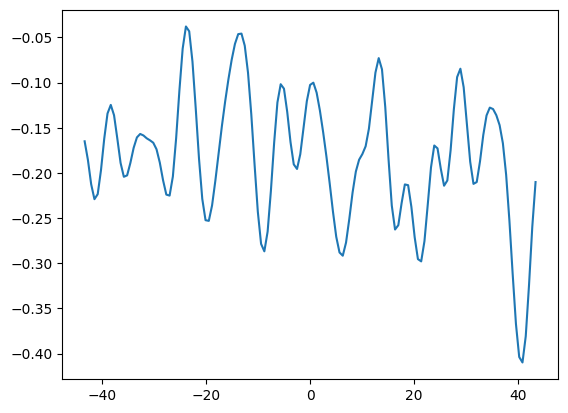

iteration 1001 loss1 is 0.00015, loss2 is 0.00011, loss3 is 0.5361, loss4 is 0.0, loss5 is 2e-05, loss6 is 1e-05


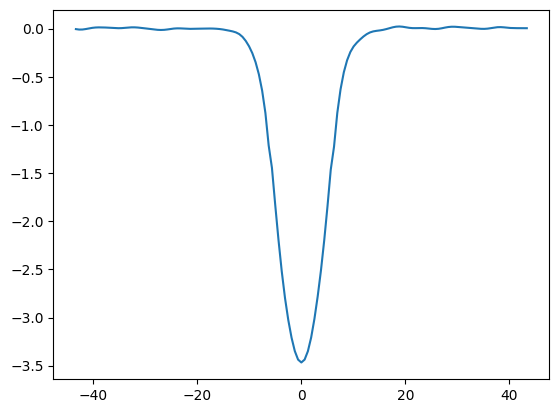

iteration 2001 loss1 is 4e-05, loss2 is 4e-05, loss3 is 0.53539, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


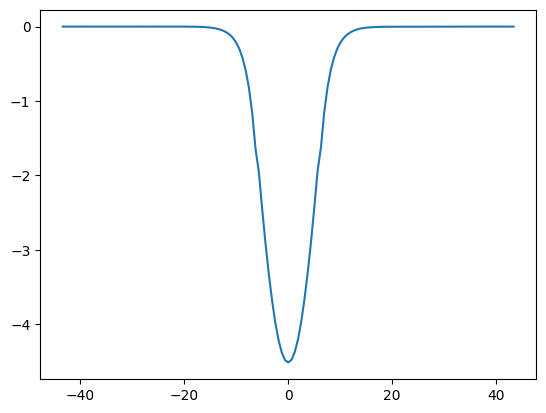

In [38]:
loss_history, rayleigh_history, mode_errors_list, u_pred = train_agent.train(2001, num_modes, weights=[1, 1, 1/10, 1, 1, 1], verbose=1, sample_new=False, plot_solution=True)

# FD Performance

In [39]:
fd_device = guides.SlabWaveguideWithFD(RIs, lambd, lengths, study, field_type, dx)
_, x, u = fd_device.evaluate(num_modes)
utils.compare_against_analytic(fd_device, x, torch.from_numpy(u))

adjusting analytic solution for Ex in a TM study


[3.4890605899623806]

# NN Performance

adjusting analytic solution for Ex in a TM study


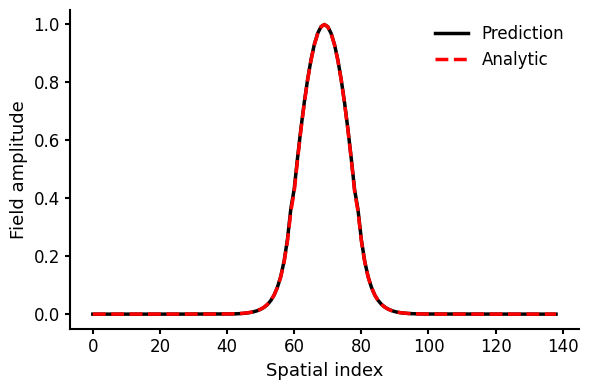

[0.5697091175010316]

In [40]:
augmented_x = torch.cat((torch.from_numpy(x).reshape(-1, 1), 1/guide.refractive_index(torch.from_numpy(x).reshape(-1, 1), format='torch')**2), dim=-1).to(device)
# base_x = torch.from_numpy(x).reshape(-1, 1).to(device)
predictions = torch.cat(([guide.underlying_model(augmented_x) for i in range(num_modes)]), dim=1)
predictions /= torch.max(abs(predictions), dim=0, keepdim=True)[0]
prediction_normed = predictions.detach().cpu() / torch.max(torch.abs(predictions.detach().cpu()), dim=0, keepdims=True)[0]
utils.compare_against_analytic(reference_device, x, -prediction_normed.detach().cpu(), plot=True)

In [41]:
x_tensor = torch.from_numpy(x)
x_tensor.requires_grad = True
x_augmented = torch.cat((x_tensor.reshape(-1, 1), 1/guide.refractive_index(torch.from_numpy(x).reshape(-1, 1), format='torch')**2), dim=-1)
base_x = torch.from_numpy(x).reshape(-1, 1).to(device)
base_x.requires_grad = True

NN_EI = [guide.calculate_eigen_value(x_augmented.to(device), 0).item()**(1/2) for i in range(num_modes)]
# NN_EI = [mode_models[i].calculate_eigen_value(x_augmented.to(memory_type), 0).item()**(1/2) for i in range(num_modes)]

_**(1/2), '\n', reference_device.evaluate_analytical(x, 3)[1], '\n', NN_EI

(array([1.53599077]),
 '\n',
 array([1.53698673, 1.49964699, 1.44869192]),
 '\n',
 [1.537279728234132])

# Multiple Modes
## Parallel mode solving

number of trainable parameters 33795
num PDE samples 139
num rayleigh samples 139
iteration 1 loss1 is 0.00832, loss2 is 0.01165, loss3 is 1.74967, loss4 is 2.98523, loss5 is 0.2083, loss6 is 0.01176


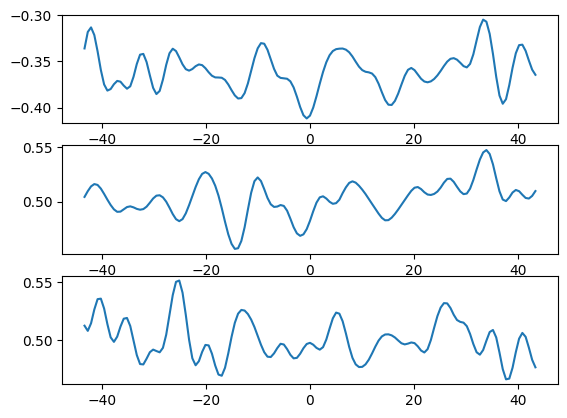

iteration 1001 loss1 is 0.00053, loss2 is 0.00093, loss3 is 1.33984, loss4 is 0.0003, loss5 is 0.00026, loss6 is 0.00123


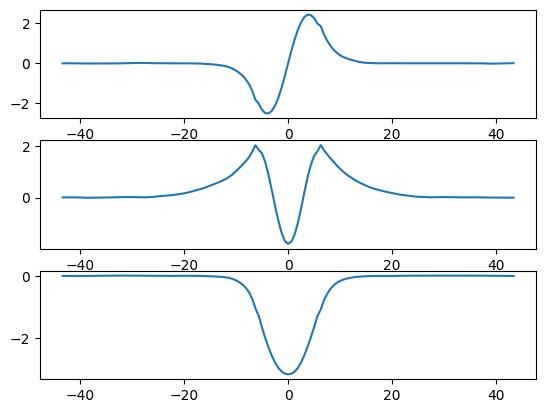

iteration 2001 loss1 is 0.00041, loss2 is 0.00117, loss3 is 1.26349, loss4 is 0.00078, loss5 is 2e-05, loss6 is 8e-05


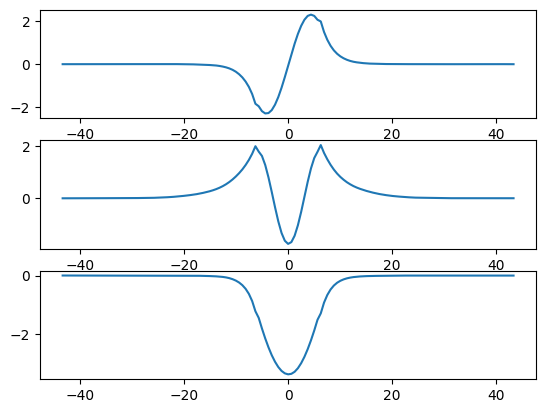

In [50]:
torch.manual_seed(42)
base_model = models.discontinuity_capturing_network(1, 128, 3, 3, ['Siren', 'Siren'])
optimzer = SOAP(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1500, 2250], gamma=0.1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))
guide = guides.SlabWaveguideWithPINNs(RIs, lambd, lengths, study, field_type, base_model, True)
train_agent = trainers.Trainer(dtype, guide, device, [samplers.uniform_grid], optimzer, scheduler, dx)
loss_history, rayleigh_history, mode_errors_list, u_iter = train_agent.train(2501, 3, weights=[2, 1, 1/20, 1, 1, 1], verbose=1, sample_new=False, plot_solution=True, u_ref=None)

## Sequential mode solving

number of trainable parameters 4417
num PDE samples 139
num rayleigh samples 139
iteration 1 loss1 is 0.00295, loss2 is 0.00237, loss3 is 0.99487, loss4 is 0.0, loss5 is 0.17051, loss6 is 0.00454


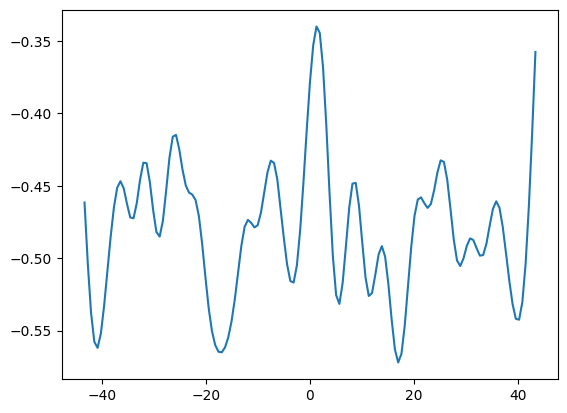

iteration 1001 loss1 is 0.00016, loss2 is 9e-05, loss3 is 0.53817, loss4 is 0.0, loss5 is 2e-05, loss6 is 3e-05


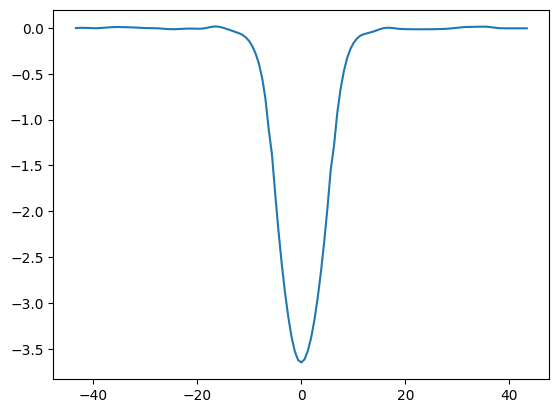

iteration 2001 loss1 is 6e-05, loss2 is 4e-05, loss3 is 0.53564, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


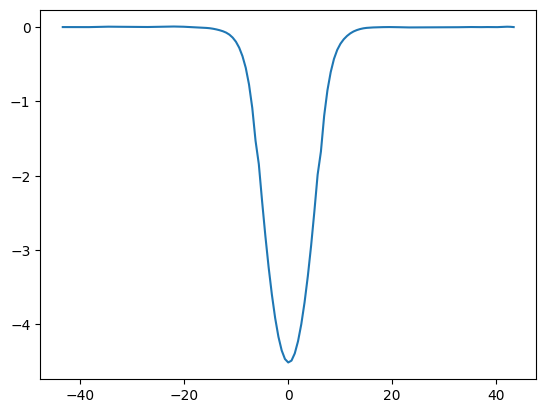

number of trainable parameters 4417
num PDE samples 139
num rayleigh samples 139
iteration 1 loss1 is 0.00116, loss2 is 3.54317, loss3 is 4.10929, loss4 is 0.04482, loss5 is 0.02213, loss6 is 3e-05


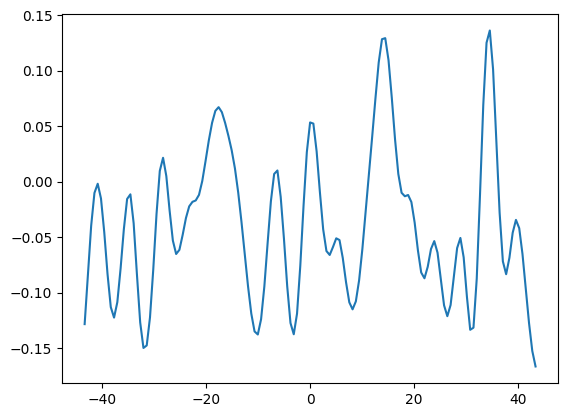

iteration 1001 loss1 is 0.00037, loss2 is 0.00022, loss3 is 0.6714, loss4 is 4e-05, loss5 is 4e-05, loss6 is 0.00021


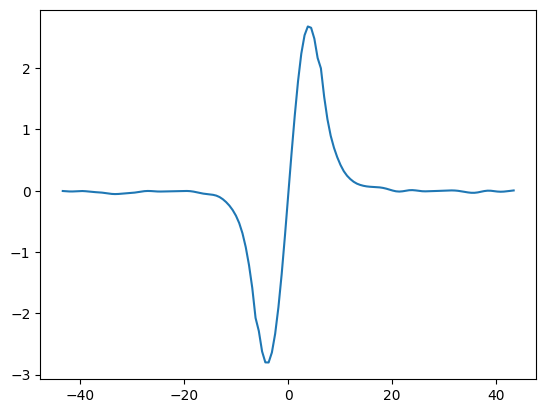

iteration 2001 loss1 is 0.0003, loss2 is 0.00023, loss3 is 0.65722, loss4 is 4e-05, loss5 is 1e-05, loss6 is 6e-05


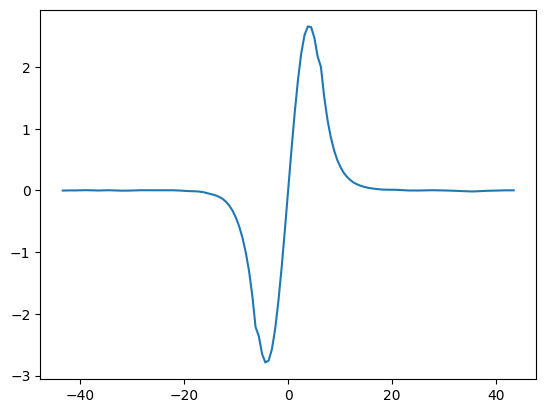

number of trainable parameters 4417
num PDE samples 139
num rayleigh samples 139
iteration 1 loss1 is 0.0038, loss2 is 0.00244, loss3 is 0.96791, loss4 is 0.15946, loss5 is 0.25546, loss6 is 0.00527


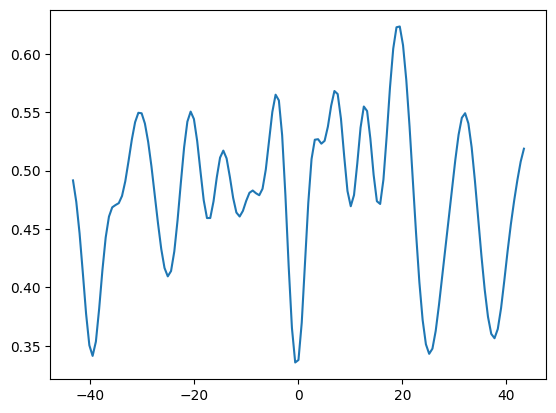

iteration 1001 loss1 is 0.00073, loss2 is 0.00052, loss3 is 0.99039, loss4 is 0.00176, loss5 is 8e-05, loss6 is 9e-05


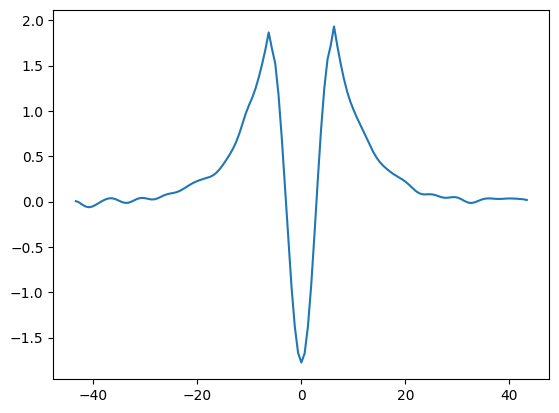

iteration 2001 loss1 is 0.00059, loss2 is 0.00081, loss3 is 0.91481, loss4 is 6e-05, loss5 is 4e-05, loss6 is 7e-05


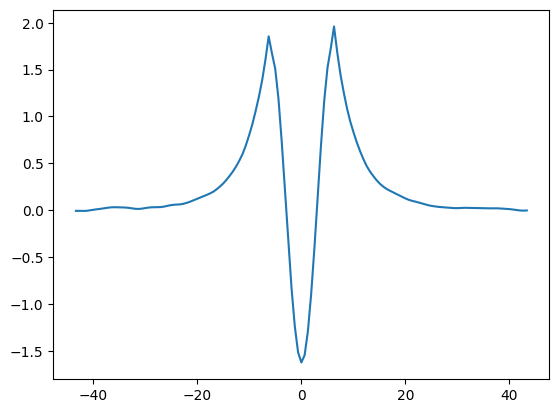

In [53]:
torch.manual_seed(42)
u_ref = []
model_networks = []
for i in range(3):
    base_model = models.discontinuity_capturing_network(1, 64, 1, 2, ['Siren', 'Siren'])
    optimzer = SOAP(base_model.parameters(), lr=1e-2, weight_decay=0)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1500, 2250], gamma=0.1)
    print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))
    guide = guides.SlabWaveguideWithPINNs(RIs, lambd, lengths, study, field_type, base_model, True)
    train_agent = trainers.Trainer(dtype, guide, device, [samplers.uniform_grid], optimzer, scheduler, dx)
    loss_history, rayleigh_history, mode_errors_list, u_iter = train_agent.train(2501, 1, weights=[1, 1, 1/(i+1)/10, 1, 1, 1], verbose=1, sample_new=False, plot_solution=True, u_ref=u_ref)
    model_networks.append(base_model)
    u_ref.append(u_iter)

In [54]:
fd_device = guides.SlabWaveguideWithFD(RIs, lambd, lengths, study, field_type, dx)
_, x, u = fd_device.evaluate(3)
utils.compare_against_analytic(fd_device, x, torch.from_numpy(u))

adjusting analytic solution for Ex in a TM study


[3.489060589962384, 4.532476397299106, 17.63796258436598]

adjusting analytic solution for Ex in a TM study


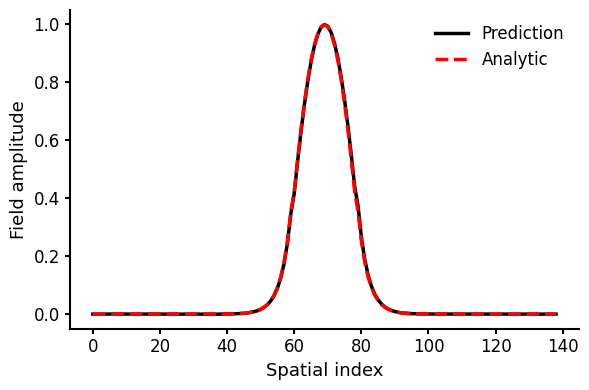

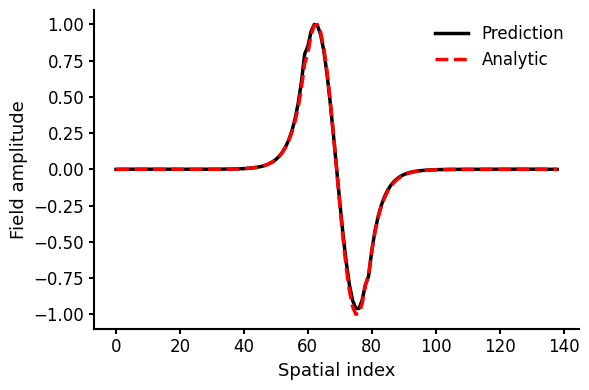

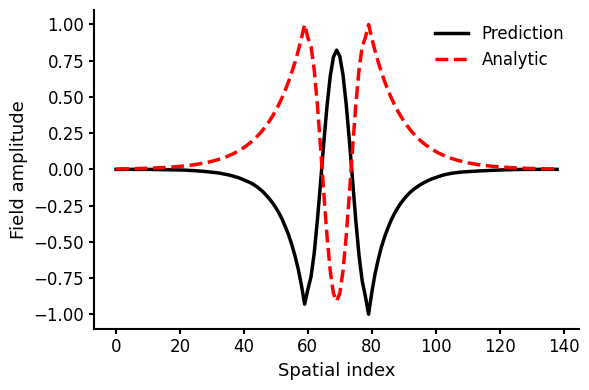

In [60]:
_, x, u = fd_device.evaluate(num_modes)
evaluation_points, eigen_modes_analytic, eigen_funcs_analytic = reference_device.evaluate_analytical(x, num_modes)
augmented_x = torch.cat((torch.from_numpy(x).reshape(-1, 1), 1/guide.refractive_index(torch.from_numpy(x).reshape(-1, 1), format='torch')**2), dim=-1).to(device)

predictions = [model_networks[i](augmented_x) for i in range(3)]
prediction_normed = torch.cat(predictions, dim=1)
prediction_normed = prediction_normed  / torch.max(torch.abs(prediction_normed), dim=0, keepdims=True)[0]

utils.compare_against_analytic(reference_device, evaluation_points, -prediction_normed.detach().cpu(), plot=True);